In [1]:
!pip install --upgrade pip
!pip install PyMuPDF

import os
import random
import numpy as np
import pandas as pd
import fitz  # pdf okuma
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 40.1 MB/s  0:00:00


In [27]:
import sys
!{sys.executable} -m pip install pyngrok


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/zor_veri_seti"

Mounted at /content/drive


In [4]:
def extract_text_from_pdf(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        full_text = [page.get_text() for page in doc]
        doc.close()
        return "\n".join(full_text).strip()
    except Exception as e:
        print(f"PDF okunamadı: {pdf_path} → Hata: {e}")
        return ""

def load_dataset_from_folders(root_dir):
    texts, labels, paths = [], [], []
    for label_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_dir):
            continue
        for pdf_file in os.listdir(class_dir):
            if not pdf_file.lower().endswith(".pdf"):
                continue
            pdf_path = os.path.join(class_dir, pdf_file)
            text = extract_text_from_pdf(pdf_path)
            if len(text.strip()) == 0:
                continue
            texts.append(text)
            labels.append(label_name)
            paths.append(pdf_path)
    return pd.DataFrame({"text": texts, "label": labels, "path": paths})

In [5]:
turkish_chars = "abcçdefgğhıijklmnoöprsştuüvyz"
def add_noise_to_text(text, drop_prob=0.15, swap_prob=0.08, char_noise_prob=0.05):
    words = text.split()
    if len(words) < 2:
        return text
    noisy_words = []
    for w in words:
        if random.random() < drop_prob:
            continue
        if random.random() < char_noise_prob and len(w) > 3:
            idx = random.randint(0, len(w)-1)
            w = w[:idx] + random.choice(turkish_chars) + w[idx+1:]
        noisy_words.append(w)
    if len(noisy_words) == 0:
        noisy_words = words
    i = 0
    while i < len(noisy_words)-1:
        if random.random() < swap_prob:
            noisy_words[i], noisy_words[i+1] = noisy_words[i+1], noisy_words[i]
            i += 2
        else:
            i += 1
    return " ".join(noisy_words)

In [6]:
df = load_dataset_from_folders(DATASET_ROOT)
print("Toplam veri:", len(df))
print("Etiketler:", sorted(df["label"].unique()))

Toplam veri: 3609
Etiketler: ['ar_ge', 'finans', 'hukuk', 'insan_kaynaklari', 'musteri_hizmetleri']


In [7]:
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    df["text"], df["label"], test_size=0.10, random_state=SEED, stratify=df["label"]
)
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

In [8]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_final_enc = le.transform(y_final_test)
num_classes = len(le.classes_)

In [9]:
X_train_noisy = X_train_clean.apply(lambda t: add_noise_to_text(t))

In [10]:
tokenizer = BertTokenizerFast.from_pretrained("dbmdz/bert-base-turkish-cased")

max_len = 512

def encode_texts(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

train_encodings = encode_texts(X_train_noisy)
test_encodings = encode_texts(X_test_clean)
final_encodings = encode_texts(X_final_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [11]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, self.labels[idx]

train_dataset = TextDataset(train_encodings, y_train_enc)
test_dataset = TextDataset(test_encodings, y_test_enc)
final_dataset = TextDataset(final_encodings, y_final_enc)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)
final_loader = DataLoader(final_dataset, batch_size=8)

In [13]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Cihaz:", device)

Cihaz: cuda


In [14]:
model = BertForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-turkish-cased",
    num_labels=num_classes
).to(device)


optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * 3  # 3 epoch
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

loss_fn = CrossEntropyLoss()


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
from copy import deepcopy

num_epochs = 3
best_model_wts = deepcopy(model.state_dict())
best_acc = 0

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    #egitim
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for batch, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(**batch)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    #val
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch, labels in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)

            outputs = model(**batch)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            val_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_epoch_loss = val_loss / total_val
    val_epoch_acc = correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)

    print(f"Epoch {epoch+1}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_epoch_loss:.4f}, Val Acc={val_epoch_acc:.4f}")

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_model_wts = deepcopy(model.state_dict())


model.load_state_dict(best_model_wts)

Epoch 1/3 - Train: 100%|██████████| 325/325 [00:53<00:00,  6.05it/s]


Epoch 1: Train Loss=0.5043, Train Acc=0.8068, Val Loss=0.0166, Val Acc=1.0000


Epoch 2/3 - Train: 100%|██████████| 325/325 [00:52<00:00,  6.18it/s]


Epoch 2: Train Loss=0.0135, Train Acc=0.9996, Val Loss=0.0059, Val Acc=1.0000


Epoch 3/3 - Train: 100%|██████████| 325/325 [00:52<00:00,  6.19it/s]


Epoch 3: Train Loss=0.0064, Train Acc=1.0000, Val Loss=0.0046, Val Acc=1.0000


<All keys matched successfully>

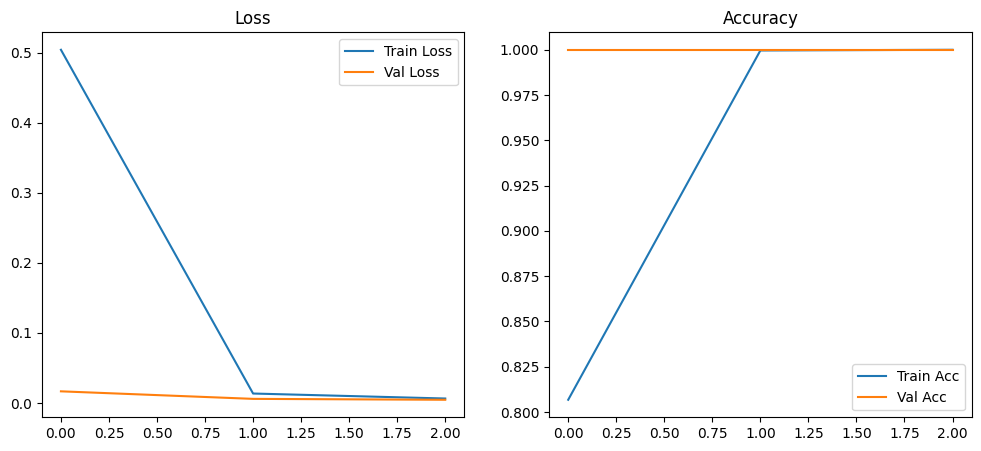

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.show()

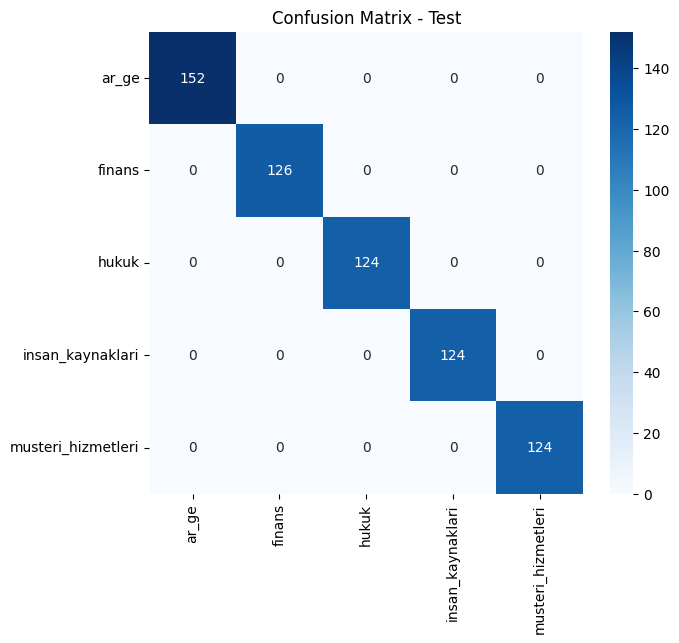

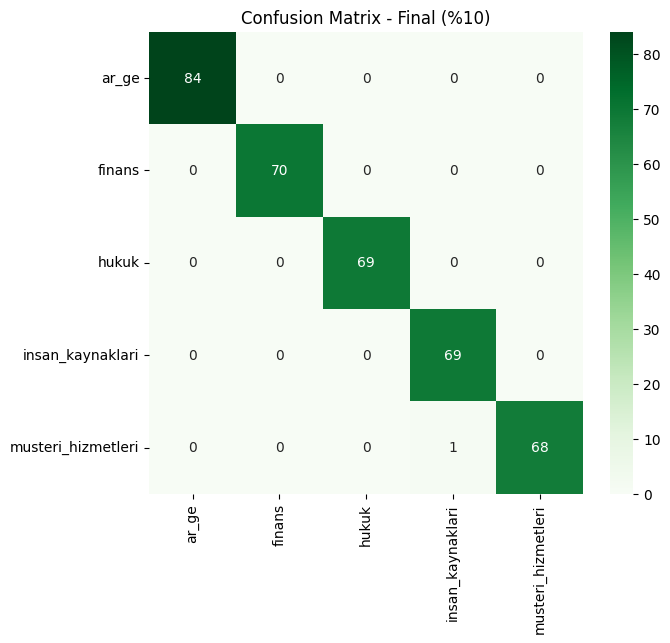

In [17]:
from sklearn.metrics import confusion_matrix

def get_preds_and_labels(dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch, labels in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

y_test_pred, y_test_true = get_preds_and_labels(test_loader)
cm_test = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm_test, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion Matrix - Test")
plt.show()


y_final_pred, y_final_true = get_preds_and_labels(final_loader)
cm_final = confusion_matrix(y_final_true, y_final_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm_final, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_, cmap="Greens")
plt.title("Confusion Matrix - Final (%10)")
plt.show()

In [18]:
import torch
from torch.nn import Softmax

def predict_pdf_department_proba_bert(model, tokenizer, label_encoder, pdf_path, max_length=512, device="cuda"):
    """
    PDF'i oku, BERT tokenizer ile encode et ve departman olasılıklarını döndür.
    """
    # PDF'den metin çek
    text = extract_text_from_pdf(pdf_path)
    if not text.strip():
        print(f"Uyarı: PDF'ten metin okunamadı -> {pdf_path}")
        return None

    # Tokenizer + encode
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    inputs = tokenizer(text, return_tensors="pt", max_length=max_length, truncation=True, padding='max_length')
    inputs = {k: v.to(device) for k, v in inputs.items()} # BU SATIR HATAYI ÇÖZER
    # Model tahmini
    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        probs = Softmax(dim=1)(logits)[0].cpu().numpy()  # 1 örnek için softmax

    # etiket
    class_names = label_encoder.classes_
    prob_dict = {cls: float(p) for cls, p in zip(class_names, probs)}
    prob_dict_sorted = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))

    return prob_dict_sorted





In [19]:

example_pdf_path = "/content/drive/MyDrive/Yesil Sertifika Sistemi (YeS-TR).pdf"

probs = predict_pdf_department_proba_bert(
    model,   # BERT model nesnesi
    tokenizer,
    le,           # LabelEncoder
    example_pdf_path,
    max_length=512,
    device=device  # cuda veya cpu
)

if probs is not None:
    print("\nBu belge için departman olasılıkları:")
    for dept, p in probs.items():
        print(f"{dept:20s} -> %{p*100:.2f}")
else:
    print("Tahmin üretilemedi (muhtemelen PDF okunamadı).")


Bu belge için departman olasılıkları:
insan_kaynaklari     -> %80.62
ar_ge                -> %9.24
hukuk                -> %6.43
finans               -> %1.97
musteri_hizmetleri   -> %1.75


In [20]:
example_pdf_path ="/content/drive/MyDrive/Kirikkale Universitesi Uzaktan Egitim Uygulama ve Arastirma Merkezi Mudurlugune Gorevlendirme.pdf"

probs = predict_pdf_department_proba_bert(
    model,   # BERT model nesnesi
    tokenizer,
    le,           # LabelEncoder
    example_pdf_path,
    max_length=512,
    device=device  # cuda veya cpu
)

if probs is not None:
    print("\nBu belge için departman olasılıkları:")
    for dept, p in probs.items():
        print(f"{dept:20s} -> %{p*100:.2f}")
else:
    print("Tahmin üretilemedi (muhtemelen PDF okunamadı).")



Bu belge için departman olasılıkları:
insan_kaynaklari     -> %86.39
hukuk                -> %7.88
ar_ge                -> %3.63
finans               -> %1.16
musteri_hizmetleri   -> %0.94


In [21]:
# MODEL KAYDETME
save_dir = "/content/drive/MyDrive/bert_model"

# Modeli kaydet
model.save_pretrained(save_dir)

# Tokenizer'ı da kaydet
tokenizer.save_pretrained(save_dir)

print(f"BERT modeli ve tokenizer {save_dir} dizinine kaydedildi.")


BERT modeli ve tokenizer /content/drive/MyDrive/bert_model dizinine kaydedildi.


In [22]:

from transformers import AutoModelForSequenceClassification, AutoTokenizer

model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json',
 './saved_model/tokenizer.json')

In [23]:
# Tokenı sisteme kaydetmek icin
!ngrok config add-authtoken 2z0uQYInm5CqPAEbBR8IQt7sIYO_2w46v7cvt6CW7cjrmgL9d

/bin/bash: line 1: ngrok: command not found


In [ ]:
!pip install flask-cors
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import os
import torch
from pyngrok import ngrok

ngrok.set_auth_token("2z0uQYInm5CqPAEbBR8IQt7sIYO_2w46v7cvt6CW7cjrmgL9d")


app = Flask(__name__)
CORS(app)

def run_model_inference(pdf_path):
    try:

        # Girişleri cihazla eşlemek için doğrudan fonksiyonu çağırıyoruz
        results = predict_pdf_department_proba_bert(
            model,
            tokenizer,
            le,
            pdf_path,
            max_length=512,
            device=device
        )
        return results
    except Exception as e:

        print(f"Detaylı Hata: {str(e)}")
        return None

@app.route('/predict', methods=['POST'])
def predict():
    temp_path = os.path.join("/content", "inference_file.pdf")
    try:
        if 'file' not in request.files:
            return jsonify({"error": "Dosya bulunamadı"}), 400

        pdf_file = request.files['file']
        pdf_file.save(temp_path)

        # GERÇEK TAHMİN
        real_prediction = run_model_inference(temp_path)

        if real_prediction is None:

            return jsonify({"error": "Cihaz uyumsuzluğu hatası! Lütfen modelin device ile eşleştiğinden emin olun."}), 500

        return jsonify(real_prediction)

    except Exception as e:
        return jsonify({"error": str(e)}), 500
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

# Ngrok ve Sunucu Başlatma
try:
    ngrok.kill()
    public_url = ngrok.connect(5000).public_url
    print("-" * 50)
    print(f"YENİ FLUTTER ADRESİ:\n{public_url}/predict")
    print("-" * 50)
except:
    pass

app.run(port=5000)

--------------------------------------------------
YENİ FLUTTER ADRESİ:
https://98f2bacf138a.ngrok-free.app/predict
--------------------------------------------------
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:39:46] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:46:23] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:46:45] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:46:54] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:03] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:07] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:12] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:26] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:30] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jan/2026 09:47:35] "POST /